This experiment runs a weak scaling evaluation on a dragonfly network. 

# 0. User Parameters, Imports, Environment

## User Parameters

In [23]:
import os

# Path to the directory containing the merlin benchmark workflow and examples
workflow_dir = '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/'


# Path to the directory where the output of the experiment runs will be stored
experiment_name = 'dragonfly_weak_scaling'

# Configuration parameters
node_counts = [1,2,4,8,16,32,64,128]
groups_per_node = [16, 32] # Total groups will scale with the number of nodes
routers_per_group = 32
hosts_per_router = 16

# Whether to force re-running experiments even if they have already been completed
# If set to 0, existing results will be used instead of rerunning experiments
FORCED = 1

# Path to the directory containing the apptainer executable
apptainer_bin_path = '/lus/scratch/crickett/software/usr/bin'

# Path where apptainer should store its cache
apptainer_cache_dir = '/lus/bnchlu1/neth/.local/apptainer/'

# URL of the SST container to be used for the workflow and the destination path where it should be saved.
# If the destination path is already created, the container will not be downloaded and the url will be ignored.
sst_container_url = 'ghcr.io/hpc-ai-adv-dev/sst-perf-track-full:16.0.0'
sst_container_dest_name = 'sst-perf-track-full.sif'


print(f'workflow_dir: {workflow_dir}')

workflow_dir: /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


## Calculated 'Constants'

In [10]:
# Full path to the SST input configuration file
sst_input_config = os.path.join(workflow_dir, 'merlin_benchmark.py')

# Directory containing per-simulation subdirectories
output_dir = os.path.join(workflow_dir, experiment_name + '_out')

# Full path to where the final .sif containerfile will live
sst_container_dest_path = os.path.join(workflow_dir, sst_container_dest_name)

# CSV file containing the consolidated experiment results after all simulations
# have been completed
experiment_result_file = os.path.join(workflow_dir, f'{experiment_name}_results.csv')

sst_input_config
sst_container_dest_path

'/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif'

## Imports

In [11]:
from workflow_utils import *
import os
import sys
sys.path.append(workflow_dir)
import workflow_args
import json
import glob
import humanfriendly
import pandas as pd
from plotnine import *

## Environment + Checks

In [12]:
os.environ["PATH"] += os.pathsep + apptainer_bin_path
#os.environ["PATH"] += os.pathsep + e4s_cl_path
os.environ["LANG"] = "C.UTF-8"
os.environ["LC_ALL"] = "C.UTF-8"
os.environ['APPTAINER_CACHEDIR'] = apptainer_cache_dir

# 1. Download and Prepare Containers

## Download containers, create `.sif`

In [13]:
cd(workflow_dir)

get_convert_to_sif()

# script expects there not to be an extension on the output file name
if os.path.exists(sst_container_dest_path):
    print(f"{sst_container_dest_path} already exists.")
else:
    run_cmd(f"./convert-to-sif.sh {sst_container_url} -o {workflow_dir} -f {sst_container_dest_name.replace('.sif', '')}")



> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif already exists.


## Prepare the e4s-cl profile

In [14]:
run_cmd(f"e4s-cl profile edit --add-files {workflow_dir}")
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.py')
run_cmd(f'e4s-cl profile edit --add-files {workflow_dir}/*.so')
run_cmd(f'e4s-cl profile edit --image {sst_container_dest_path}')

> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.py


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.py already in profile's files


> e4s-cl profile edit --add-files /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark//*.so


File /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/*.so already in profile's files


> e4s-cl profile edit --image /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif


## Check that the profile injects a host MPI

If the selected e4s-cl profile has no MPI library bound, e4s-cl performs no MPI
substitution. The container's own MPI then finds no process manager and falls
back to *singleton init*, so every task silently becomes rank 0 of a 1-rank job
instead of one N-rank simulation.


In [15]:
check_mpi_binding(sst_container_dest_path)

e4s-cl profile : sst-experiments
profile image  : /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif
container SST  : /opt/SST/16.0.0/libexec/sstsim.x
container MPI  : libmpi.so.12
bound host MPI : libmpi_cray.so.12 -> /opt/cray/pe/lib64/libmpi_cray.so.12
bound host PMI : libpals.so.0, libpmi.so.0, libpmi2.so.0
OK: e4s-cl will inject a host MPI into the container.


True

# 2. Build Benchmarks

In [16]:
# Run Make within the container
# We have to create and mount this .conf file for SST to use when running
run_cmd('touch sstsimulator.conf')
run_in_container('make -j10', sst_container_dest_path, additional_apptainer_args=f'--bind sstsimulator.conf:{os.getenv("HOME")}/.sst/sstsimulator.conf')

> touch sstsimulator.conf
> ['apptainer', 'exec', '--no-home', '--bind', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark:/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--pwd', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark', '--bind', 'sstsimulator.conf:/home/users/neth/.sst/sstsimulator.conf', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/sst-perf-track-full.sif', 'bash', '-lc', 'make -j10']


/opt/SST/16.0.0/bin//sst-register merlin_benchmark merlin_benchmark_LIBDIR=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark


# 3. Generate Argument Tuples

In [17]:
run_specs = []
for node_count in node_counts:
    for gpn in groups_per_node:
        num_groups = gpn * node_count
        run_specs += workflow_args.generate_merlin_run_specs(
        node_counts = (node_count,),
        topologies=('dragonfly',),
        global_params={'stop_at': (200),
                       'verbose': 0},
        dragonfly_params={
            'dragonfly_hosts_per_router': (hosts_per_router,),
            'dragonfly_num_groups': (num_groups,),
            'dragonfly_routers_per_group' : (routers_per_group,)
        },
        experiment_name=experiment_name,
        trials=3)
print(f"Generated {len(run_specs)} run specifications.")
print(f'Example spec: ', run_specs[0])

Generated 24 run specifications.
Example spec:  MerlinRunSpec(run_id='5c0f04b8d6', run_name='dragonfly_weak_scaling_dragonfly_n1_r1_5c0f04b8d6_t1', launcher={'srun': ['--nodes=1', '--ntasks-per-node=1'], 'mpirun': ['-n', '1', '-N', '1']}, sst_args=['--timing-info=3', '--parallel-load=SINGLE'], config_args=['--dragonfly-adaptive-threshold', '2.0', '--dragonfly-algorithm', 'minimal', '--dragonfly-global-routing-mode', 'absolute', '--dragonfly-hosts-per-router', '16', '--dragonfly-intergroup-links', '1', '--dragonfly-num-groups', '16', '--dragonfly-routers-per-group', '32', '--flit-size-bytes', '8', '--link-bw-gbps', '4', '--link-lat-ns', '1', '--stop-at', '200ns', '--tg-input-buf-size', '4kB', '--tg-input-latency', '20ns', '--tg-output-buf-size', '4kB', '--tg-output-latency', '20ns', '--topology', 'dragonfly', '--verbose', '0', '--xbar-bw-gbps', '4'], metadata={'experiment_name': 'dragonfly_weak_scaling', 'run_name': 'dragonfly_weak_scaling_dragonfly_n1_r1_5c0f04b8d6_t1', 'run_id': '5c0f

# 4. Launch Runs

In [18]:

os.makedirs(output_dir, exist_ok=True)

for run_spec in run_specs:
    run_output_dir = os.path.join(output_dir, run_spec.run_name)
    os.makedirs(run_output_dir, exist_ok=True)
    cd(run_output_dir)

    status_file_path = os.path.join(run_output_dir, 'status.txt')

    if os.path.exists(status_file_path):
        with open(status_file_path, 'r') as f:
            status = f.read().strip()
        if not FORCED and status in ['COMPLETED', 'SUBMITTED']:
            print(f'Skipping {run_spec.run_name} as it is already {status}')
            continue

    log_file = os.path.join(run_output_dir, 'run.log')
    error_file = os.path.join(run_output_dir, 'run.err')
    profiling_output_file = os.path.join(run_output_dir, 'profiling.json')

    param_file = os.path.join(run_output_dir, 'params.json')
    with open(param_file, 'w') as f:
        json.dump(run_spec.to_dict(), f, indent=2)


    srun_part = " ".join(run_spec.launcher["srun"])
    sst_part = " ".join(run_spec.sst_args)
    config_part = " ".join(run_spec.config_args)

    launch_cmd = (
        f"e4s-cl launch srun --output={log_file} --error={error_file} "
        f"{srun_part} \\\n\t -- sst --profiling-output={profiling_output_file} --timing-info=3 {sst_input_config} "
        f"{sst_part} \\\n\t -- {config_part}"
    )

    
    sbatch_script_path = os.path.join(run_output_dir, 'run.sbatch')

    with open(sbatch_script_path, 'w') as f:
        f.write(f"#!/bin/bash\n")
        f.write(f"echo 'LAUNCHED' > {status_file_path}\n")
        f.write(f"{launch_cmd}\n")
        f.write(f"if [ $? -eq 0 ]; then\n")
        f.write(f"    echo 'COMPLETED' > {status_file_path}\n")
        f.write(f"else\n")
        f.write(f"    echo 'FAILED' > {status_file_path}\n")
        f.write(f"fi\n")

    os.chmod(sbatch_script_path, 0o755)

    sbatch_log = os.path.join(run_output_dir, 'sbatch.log')
    sbatch_err = os.path.join(run_output_dir, 'sbatch.err')
    sbatch_cmd = f"sbatch --job-name={experiment_name} --output={sbatch_log} --error={sbatch_err} {srun_part} {sbatch_script_path}"
    sbatch_submit_file = os.path.join(run_output_dir, 'sbatch_submit_cmd.txt')
    with open(sbatch_submit_file, 'w') as f:
        f.write(f"{sbatch_cmd}\n")

    with open(status_file_path, 'w') as f:
        f.write('SUBMITTED\n')
    run_cmd(sbatch_cmd)

    cd(workflow_dir)

> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n1_r1_5c0f04b8d6_t1
> sbatch --job-name=dragonfly_weak_scaling --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n1_r1_5c0f04b8d6_t1/sbatch.log --error=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n1_r1_5c0f04b8d6_t1/sbatch.err --nodes=1 --ntasks-per-node=1 /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n1_r1_5c0f04b8d6_t1/run.sbatch
Submitted batch job 1642039
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n1_r1_5c0f04b8d6_t2
> sbatch --job-name=dragonfly_weak_scaling --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/drag

Submitted batch job 1642043
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n2_r1_84fae7902b_t3
> sbatch --job-name=dragonfly_weak_scaling --output=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n2_r1_84fae7902b_t3/sbatch.log --error=/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n2_r1_84fae7902b_t3/sbatch.err --nodes=2 --ntasks-per-node=1 /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n2_r1_84fae7902b_t3/run.sbatch
Submitted batch job 1642044
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/
> cd /lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n4_r1_9923ab514d_t1
> sbatch --job-name=dragonfly_weak_scaling --outp

# 5. Wait for Job Completion

In [19]:
wait_for_jobs(job_name=experiment_name)

Waiting for jobs to complete... Queue length: 24


Waiting for jobs to complete... Queue length: 24
Waiting for jobs to complete... Queue length: 24
Waiting for jobs to complete... Queue length: 24
Waiting for jobs to complete... Queue length: 24
Waiting for jobs to complete... Queue length: 22
Waiting for jobs to complete... Queue length: 21
Waiting for jobs to complete... Queue length: 12
Waiting for jobs to complete... Queue length: 8
Waiting for jobs to complete... Queue length: 6
Waiting for jobs to complete... Queue length: 5
Waiting for jobs to complete... Queue length: 4
Waiting for jobs to complete... Queue length: 4
Waiting for jobs to complete... Queue length: 4
Waiting for jobs to complete... Queue length: 4
Waiting for jobs to complete... Queue length: 4
Waiting for jobs to complete... Queue length: 4
Waiting for jobs to complete... Queue length: 3
Waiting for jobs to complete... Queue length: 3
Waiting for jobs to complete... Queue length: 3
Waiting for jobs to complete... Queue length: 2
Waiting for jobs to complete... Q

KeyboardInterrupt: 

# 6. Collect Simulation Results

In [24]:
result_files = glob.glob(f'{output_dir}/**/profiling.json', recursive=True)
    
print(result_files)
columns = []
for result_file in result_files:
    column_data = {}
    param_file = result_file.replace('profiling.json', 'params.json')
    if os.path.exists(param_file):
        with open(param_file, 'r') as f:
            params = json.load(f)
            for key, value in params.items():
                column_data[key] = value

    with open(result_file, 'r') as f:
        content = json.load(f)
        regions = content['regions']
        column_data['total_duration_s'] = humanfriendly.parse_timespan(regions['total']['duration'])    
        column_data['build_duration_s'] = humanfriendly.parse_timespan(regions['total']['build']['duration'])
        column_data['execute_duration_s'] = humanfriendly.parse_timespan(regions['total']['execute']['duration'])

        column_data['total_memory_gib'] = humanfriendly.parse_size(regions['total']['total_memory']) / (1024.0 ** 3)
        column_data['build_memory_gib'] = humanfriendly.parse_size(regions['total']['build']['total_memory']) / (1024.0 ** 3)
        column_data['execute_memory_gib'] = humanfriendly.parse_size(regions['total']['execute']['total_memory']) / (1024.0 ** 3)

        column_data['global_max_rss_gib'] = humanfriendly.parse_size(content['resources']['global_max_rss']) / (1024.0 ** 3)
        column_data['local_max_rss_gib'] = humanfriendly.parse_size(content['resources']['local_max_rss']) / (1024.0 ** 3)
        column_data['dragonfly_groups_per_node'] = column_data['dragonfly_num_groups'] / column_data['node_count']
        column_data['dragonfly_num_routers'] = column_data['dragonfly_routers_per_group'] * column_data['dragonfly_num_groups']
    param_file = result_file.replace('profiling.json', 'params.json')
    if os.path.exists(param_file):
        with open(param_file, 'r') as f:
            params = json.load(f)
            for key, value in params.items():
                column_data[key] = value
    #print(column_data)
    columns.append(column_data)


df = pd.DataFrame(columns)

df = aggregate_over_trials(df)
df.to_csv(experiment_result_file, index=False)


['/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n4_r1_9923ab514d_t2/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n2_r1_84fae7902b_t3/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n4_r1_9923ab514d_t1/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n8_r1_4137b69d35_t1/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n32_r1_90977098b0_t2/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfly_n32_r1_90977098b0_t3/profiling.json', '/lus/bnchlu1/neth/sst-benchmarks/merlin_benchmark/dragonfly_weak_scaling_out/dragonfly_weak_scaling_dragonfl

# 7. Analyze Results

In [25]:
df = pd.read_csv(experiment_result_file)
df.head()

,run_id,experiment_name,topology,node_count,rank_count,mpirun_command,stop_at,verbose,flit_size_bytes,link_bw_gbps,...,build_memory_gib_mean,execute_memory_gib_min,execute_memory_gib_max,execute_memory_gib_mean,global_max_rss_gib_min,global_max_rss_gib_max,global_max_rss_gib_mean,local_max_rss_gib_min,local_max_rss_gib_max,local_max_rss_gib_mean
0,4137b69d35,dragonfly_weak_scaling,dragonfly,8,1,mpirun -n 8 -N 1 sst --timing-info=3 --paralle...,200ns,0,8,4,...,3.568263,3.976971,3.981953,3.980246,4.072422,4.077526,4.075775,0.511906,0.512172,0.512052
1,4575f10801,dragonfly_weak_scaling,dragonfly,64,1,mpirun -n 64 -N 1 sst --timing-info=3 --parall...,200ns,0,8,4,...,38.234641,43.379609,43.396559,43.385507,44.420734,44.438057,44.426757,0.697327,0.698590,0.697977
2,475d98a145,dragonfly_weak_scaling,dragonfly,128,1,mpirun -n 128 -N 1 sst --timing-info=3 --paral...,200ns,0,8,4,...,98.669591,112.618320,112.632290,112.626391,115.321949,115.335919,115.329710,0.905197,0.905789,0.905584
3,585eca31ca,dragonfly_weak_scaling,dragonfly,16,1,mpirun -n 16 -N 1 sst --timing-info=3 --parall...,200ns,0,8,4,...,7.487327,8.377470,8.381121,8.378696,8.578524,8.582268,8.579784,0.538506,0.538757,0.538673
4,5c0f04b8d6,dragonfly_weak_scaling,dragonfly,1,1,mpirun -n 1 -N 1 sst --timing-info=3 --paralle...,200ns,0,8,4,...,0.381326,0.429917,0.431772,0.430917,0.440235,0.442135,0.441259,0.440235,0.442135,0.441259


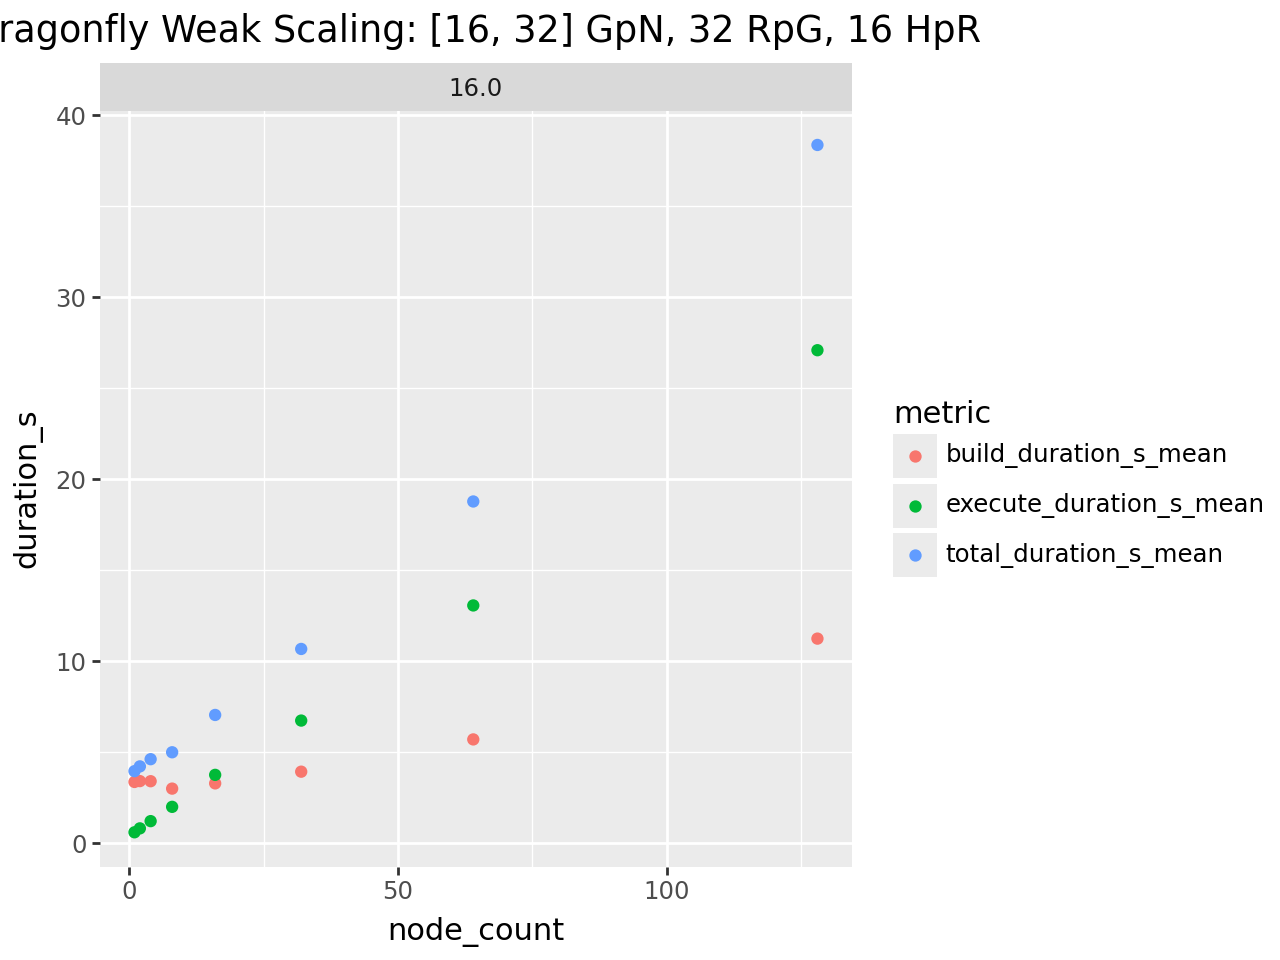

In [27]:
time_df = df.melt(id_vars=['node_count', 'dragonfly_groups_per_node'], value_vars=['build_duration_s_mean', 'execute_duration_s_mean', 'total_duration_s_mean'], var_name='metric', value_name='duration_s')
p = ggplot(time_df, aes(x='node_count', y='duration_s', color='metric'))
p += geom_point()
p += facet_wrap('dragonfly_groups_per_node')
p += labs(title=f'Dragonfly Weak Scaling: {groups_per_node} GpN, {routers_per_group} RpG, {hosts_per_router} HpR')
p

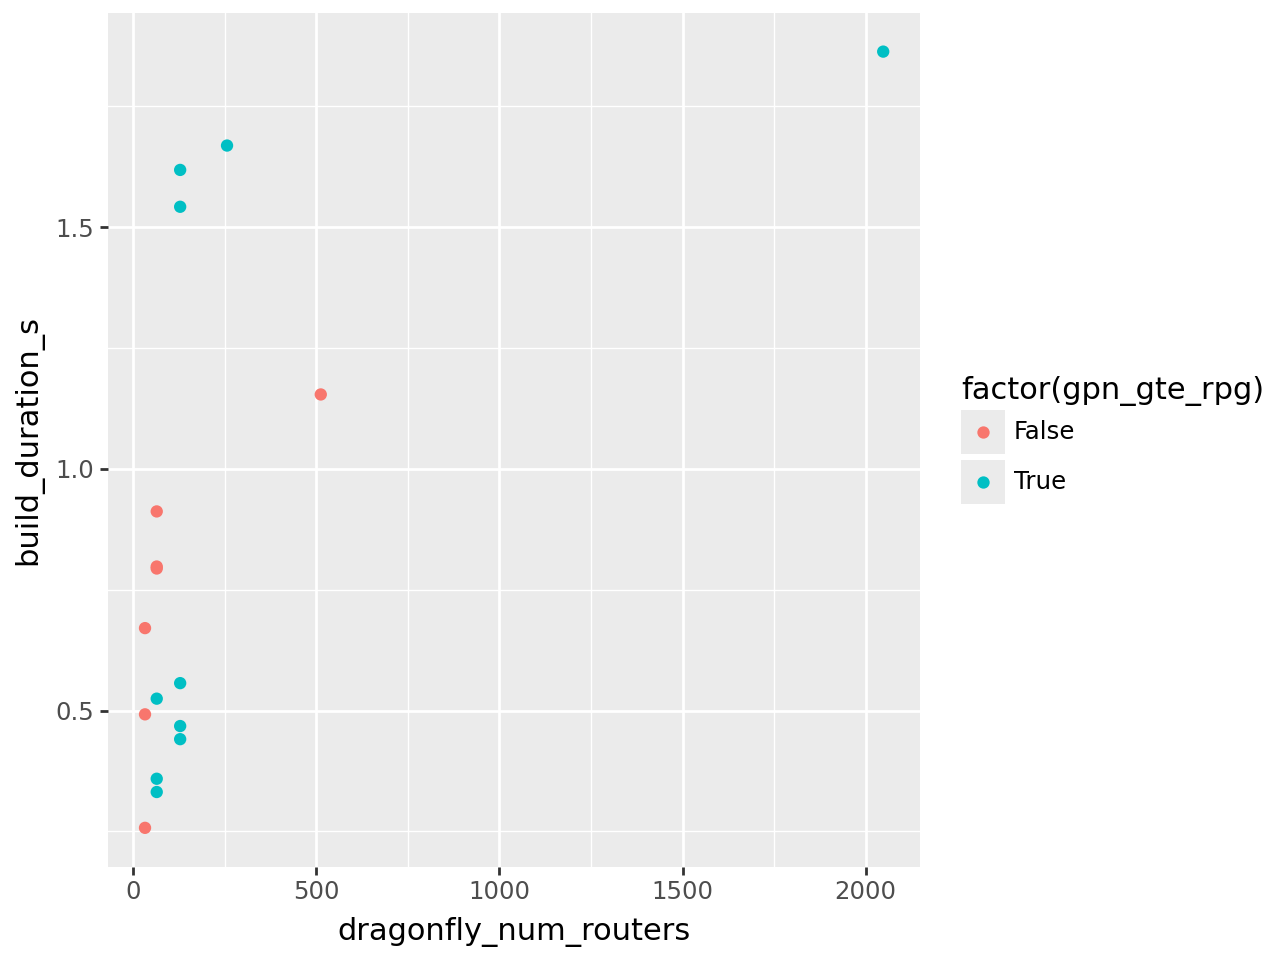

In [ ]:
df['gpn_gte_rpg'] = df['dragonfly_groups_per_node'] >= df['dragonfly_routers_per_group']
p = ggplot(df, aes(x='dragonfly_num_routers', y='build_duration_s', color='factor(gpn_gte_rpg)'))
p += geom_point()
p

In [ ]:
df['verbose']

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
Name: verbose, dtype: int64